### Data preprocessing

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table
from zero_point import zpt
import warnings
warnings.simplefilter("always", UserWarning)

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [23]:
''' Required functions '''

deg2rad = np.pi/180.

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

###  Functions for computing the vertical velocity
def pm_eq_to_pm_gal(mu_alpha_cos_delta, mu_delta, alpha, delta):
    ''' In- and Output in degrees per arbitrary unit of time'''
    # from https://arxiv.org/pdf/1306.2945
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    _delta = delta * deg2rad
    _alpha = alpha * deg2rad
    C1 = np.sin(deltaG)*np.cos(_delta) - np.cos(deltaG)*np.sin(_delta)*np.cos(_alpha-alphaG)
    C2 = np.cos(deltaG)*np.sin(_alpha-alphaG)
    cos_b = np.sqrt(C1**2 + C2**2)
    mu_l_cos_b = (C1*mu_alpha_cos_delta + C2*mu_delta)/cos_b
    mu_b = (-C2*mu_alpha_cos_delta + C1*mu_delta)/cos_b
    return mu_l_cos_b, mu_b

def ra_dec_to_l_b(ra, dec):
    '''From ra and dec in degrees to l and b in degrees'''
    # See http://www.iausofa.org/2023_1011_C/sofa/icrs2g.c
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    l_ANGE = 32.93192 * deg2rad
    _ra = ra * deg2rad
    _dec = dec * deg2rad
    
    b = np.arcsin(np.cos(_dec)*np.cos(deltaG)*np.cos(_ra-alphaG)+np.sin(_dec)*np.sin(deltaG))
    x = np.sin(_ra-alphaG)*np.cos(_dec)
    y = np.sin(_dec)*np.cos(deltaG)-np.cos(_dec)*np.sin(deltaG)*np.cos(_ra-alphaG)
    
    l = np.arctan2(y, x) + l_ANGE
    l = np.mod(l, 2.*np.pi)
    
    return l/deg2rad, b/deg2rad

def compute_vz(plx, ra, dec, vlos, pm_ra, pm_dec,):
    """From 
    parallax in mas,
    ra and dec in degrees,
    vlos in km/s,
    pm_ra and pm_dec in mas/yr,
    to vz in km/s"""
    deg2rad = np.pi / 180.
    yr_to_sec = 3.154e7
    pc_to_km = 3.086e13
    mas_to_deg = 1./60./60./1000.
    _pm_ra = pm_ra * mas_to_deg # deg/yr
    _pm_dec = pm_dec * mas_to_deg # deg/yr
    
    pm_l, pm_b = pm_eq_to_pm_gal(_pm_ra, _pm_dec, ra, dec)  # deg/yr
    pm_l *=  deg2rad / yr_to_sec # rad/s
    pm_b *= deg2rad / yr_to_sec # rad/s

    l, b = ra_dec_to_l_b(ra, dec) # deg
    l *= deg2rad # rad
    b *= deg2rad # rad

    r = r_from_plx(plx) * pc_to_km  # km
    v_z = vlos * np.sin(b) + r * np.cos(b) * pm_b  # km/s
    
    return v_z


def compute_phi(plx, ra, dec):
    '''latitude relative to the galactic center in right handed coordinates'''

    deg2rad = np.pi / 180.
    pc_to_km = 3.086e13

    l, b = ra_dec_to_l_b(ra, dec) # deg
    l *= deg2rad # rad
    b *= deg2rad # rad

    r = r_from_plx(plx) * pc_to_km  # km
    R_sun = 8.26e3 *pc_to_km # km
    d = r*np.cos(b)

    if l<=np.pi:
        c = np.sqrt(R_sun**2 + d**2 - 2*R_sun*d*np.cos(l))
        phi = 2*np.pi - np.arccos((R_sun**2 + c**2 - d**2)/(2*R_sun*c))
    if l>np.pi:
        c = np.sqrt(R_sun**2 + d**2 - 2*R_sun*d*np.cos(2*np.pi-l))
        phi = np.arccos((R_sun**2 + c**2 - d**2)/(2*R_sun*c))

    return phi

def compute_vr_sun(plx, ra, dec, vlos, pm_ra, pm_dec,): 

    vc = 238 # km/s
    U = 11.1 # km/s
    V = 12.24 # km/s
    W = 7.25 # km/s

    l,b = ra_dec_to_l_b(ra, dec)
    l *= deg2rad
    b *= deg2rad

    phi = compute_phi(plx, ra, dec)

    b_sun = np.tan(14.5/6.26e3)# rad
    if l<=np.pi:
        vr_sun = (vc+V)*np.sin(2*np.pi-phi) - U*np.cos(b_sun)*np.cos(2*np.pi-phi) # pos away, neg towards gal center
    if l>np.pi:
        vr_sun = -(vc+V)*np.sin(phi) - U*np.cos(b_sun)*np.cos(phi)

    return vr_sun

def compute_vr(plx, ra, dec, vlos, pm_ra, pm_dec,):
    """From 
    parallax in mas,
    ra and dec in degrees,
    vlos in km/s,
    pm_ra and pm_dec in mas/yr,
    to vr in km/s"""
    deg2rad = np.pi / 180.
    yr_to_sec = 3.154e7
    pc_to_km = 3.086e13
    mas_to_deg = 1./60./60./1000.
    _pm_ra = pm_ra * mas_to_deg # deg/yr
    _pm_dec = pm_dec * mas_to_deg # deg/yr
    
    pm_l, pm_b = pm_eq_to_pm_gal(_pm_ra, _pm_dec, ra, dec)  # deg/yr
    pm_l *=  deg2rad / yr_to_sec # rad/s
    pm_b *= deg2rad / yr_to_sec # rad/s

    l, b = ra_dec_to_l_b(ra, dec) # deg
    l *= deg2rad # rad
    b *= deg2rad # rad

    r = r_from_plx(plx) * pc_to_km  # km
    phi = compute_phi(plx, ra, dec)
    vr_sun = compute_vr_sun(plx, ra, dec, vlos, pm_ra, pm_dec)
    if l<=np.pi:
        v_r = - vlos * np.cos(b)*np.cos(l-phi) + r * pm_b * np.sin(b)*np.cos(l-phi) + r * pm_l * np.sin(l-phi) # km/s

    if l>np.pi:
        v_r = vlos * np.cos(b)*np.cos(l-phi-np.pi) - r * pm_b * np.sin(b)*np.cos(l-phi-np.pi) - r * pm_l * np.sin(l-phi-np.pi)
    
    return v_r-vr_sun


In [24]:
''' Loading data '''
tab2 = Table.read("C:/Users/Ruben/Documents/Bachelorarbeit/final_data_query.vot")
zpt.load_tables()

C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\zero_point\zpt.py:205: UserWarning: The apparent magnitude of one or more of the sources is outside the expected range (6-21 mag). 
                Outside this range, there is no further interpolation, thus the values at 6 or 21 are returned.
  warnings.warn(
C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\zero_point\zpt.py:220: UserWarning: The nu_eff_used_in_astrometry of some of the 5p source(s) is outside the expected range (1.1-1.9 
                mag). Outside this range, the zero-point calculated can be seriously wrong.
  warnings.warn(
C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\zero_point\zpt.py:233: UserWarning: The pseudocolour of some of the 6p source(s) is outside the expected range (1.24-1.72 mag).
                 The maximum corrections are reached already at 1.24 and 1.72
  warnings.warn(


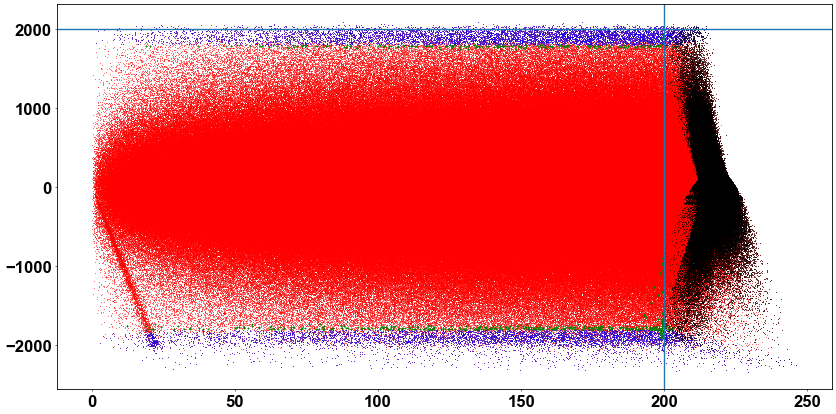

In [25]:
''' Restricting data in absolute magnitude and color '''

apparent_magnitude2 = np.array(tab2["phot_g_mean_mag"]) # 3.15 - 19.00
nueff2 = np.array(tab2["nu_eff_used_in_astrometry"])
psc2 = np.array(tab2["pseudocolour"])
ecl_lat2 = np.array(tab2["ecl_lat"])
soltype2 = np.array(tab2["astrometric_params_solved"])

zpvals2 = zpt.get_zpt(apparent_magnitude2, nueff2, psc2, ecl_lat2, soltype2)
parallax2 = np.array(tab2["parallax"])

dist_pc2_uncorrected = r_from_plx(parallax2) # in pc
r_pc2_uncorrected = dist_pc2_uncorrected * np.cos(np.array(tab2["b"])*deg2rad) # in pc
z_pc2_uncorrected = dist_pc2_uncorrected * np.sin(np.array(tab2["b"])*deg2rad) +14.5 # in pc
parallax2 = parallax2 - zpvals2

dist_pc2 = r_from_plx(parallax2) # in pc
r_pc2 = dist_pc2 * np.cos(np.array(tab2["b"])*deg2rad) # in pc
z_pc2 = dist_pc2 * np.sin(np.array(tab2["b"])*deg2rad) +14.5 # in pc
absolute_magnitude2 = apparent_magnitude2 - 5.*np.log10(dist_pc2) + 5

g_rp2 = np.array(tab2["g_rp"]) # in mag
bp_g2 = np.array(tab2["bp_g"]) # in mag
bp_rp2 = np.array(tab2["bp_rp"]) # in mag

x = g_rp2 # chosen color-measurand for data selection

# all cuts to select a tracer population (cuts are difined as color dependent cuts in absolute magnitude)'''
ou = 'o3m3' # final selection of cuts, to limit data to the main sequence
o3 = (6-7.4)/(0.79-1.04)*(x-0.79)+6
m3 = (6-7.4)/(0.67-0.9)*(x-0.67+2*0.032)+6

# final selection to restrict the used interval of the main sequence
left2 = 6
right2 = 7.4

tab = tab2[(r_pc2 < 200.)&(abs(z_pc2)<1800)&(absolute_magnitude2>=o3)&(absolute_magnitude2<=m3)&(absolute_magnitude2<=right2)&(absolute_magnitude2>=left2)]

''' Plotting '''

fig = plt.figure(figsize=(20,10))
plt.scatter(r_pc2, z_pc2, marker='.', color='red', s=0.5)
plt.scatter(r_pc2[np.where(abs(z_pc2_uncorrected)>1900)], z_pc2[np.where(abs(z_pc2_uncorrected)>1900)], marker='.', color='blue', s=0.5)
plt.scatter(r_pc2[np.where((abs(z_pc2_uncorrected)>1900)&(abs(z_pc2)<=1800))], z_pc2[np.where((abs(z_pc2_uncorrected)>1900)&(abs(z_pc2)<=1800))], marker='x', color='green', s=2)
plt.scatter(r_pc2[np.where((r_pc2_uncorrected>215))], z_pc2[np.where(r_pc2_uncorrected>215)], marker='.', color='black', s=0.5)
plt.scatter(r_pc2[np.where((r_pc2_uncorrected>215)&(r_pc2<=200))], z_pc2[np.where((r_pc2_uncorrected>215)&(r_pc2<=200))], marker='x', color='green', s=4)
plt.axhline(2000)
plt.axvline(200)
fig.set_dpi(50)
plt.show()

C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\zero_point\zpt.py:205: UserWarning: The apparent magnitude of one or more of the sources is outside the expected range (6-21 mag). 
                Outside this range, there is no further interpolation, thus the values at 6 or 21 are returned.
  warnings.warn(
C:\Users\Ruben\AppData\Roaming\Python\Python311\site-packages\zero_point\zpt.py:233: UserWarning: The pseudocolour of some of the 6p source(s) is outside the expected range (1.24-1.72 mag).
                 The maximum corrections are reached already at 1.24 and 1.72
  warnings.warn(


Sterne ohne Parallaxe oder Unsicherheit:  0


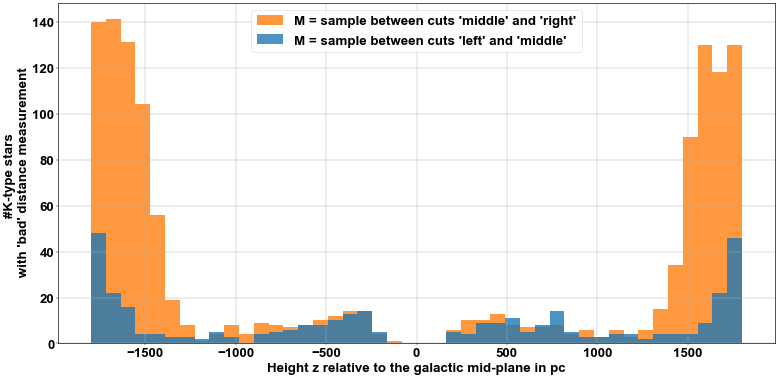

In [26]:
''' investigation of z dependence of stars with inaccurate parallaxe measurment '''

apparent_magnitude = np.array(tab["phot_g_mean_mag"]) # 3.15 - 19.00
nueff = np.array(tab["nu_eff_used_in_astrometry"])
psc = np.array(tab["pseudocolour"])
ecl_lat = np.array(tab["ecl_lat"])
soltype = np.array(tab["astrometric_params_solved"])

zpvals = zpt.get_zpt(apparent_magnitude, nueff, psc, ecl_lat, soltype)

parallax = tab["parallax"] - zpvals

dist_pc = r_from_plx(np.array(tab["parallax"])) # in pc
absolute_magnitude = apparent_magnitude - 5.*np.log10(dist_pc) + 5
g_rp = np.array(tab["g_rp"]) # in mag

left = 6
right = 7.4
middle = 6.7 # middle cut to seperate subsamples

parallax_over_error = np.array(tab["parallax"]/tab["parallax_error"])
print("Sterne ohne Parallaxe oder Unsicherheit: ", np.sum(np.isnan(parallax_over_error)))
m = 5
mask0 = parallax_over_error > m
group1 = (absolute_magnitude[~mask0] >= left) & (absolute_magnitude[~mask0] < middle)
group2 = (absolute_magnitude[~mask0] >= middle) & (absolute_magnitude[~mask0] <= right)
z_out = (dist_pc*np.sin(tab["b"]*deg2rad))[~mask0]
absolute_magnitude_out = absolute_magnitude[~mask0]

fig = plt.figure(figsize=(20,10))
plt.hist([z_out[group1], z_out[group2]], bins=44, alpha=0.8, histtype='stepfilled', range=(-1800, 1800), label=["M = sample between cuts 'left' and 'middle'", "M = sample between cuts 'middle' and 'right'"])
plt.xlabel("Height z relative to the galactic mid-plane in pc")
plt.ylabel("#K-type stars \n with 'bad' distance measurement")
plt.grid()
plt.tight_layout()
plt.legend()
plt.savefig("plots/Height_distribution_bad_distance_measurement_colour_new.png")
fig.set_dpi(40)
plt.show()

In [27]:
''' Selecting subsamples '''
mask0 = parallax_over_error > 0 # minimal parallax over error not needed anymore due to consideration of statistical influence of uncertainty in the variational inference
print("Requirement: parallax/standarterror(parallax) is larger than {}. This ensures useful parallax measurment. Removes an additional {:.2e} sources".format(0, np.nansum(~mask0)))
print("We are left with {:.2e} sources".format(np.nansum(mask0)))

# Cylinder symmetrical around galactic plane
height = 1800. # pc
mask1 = (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)<height-14.5) & (dist_pc[mask0]*np.sin(tab["b"][mask0]*deg2rad)>-height-14.5)
print("Requirement: Inside the cylinder of 2 * {} pc hight (centered at galactic plane!). Removes an additional {:.2e} sources".format(height, np.nansum(~mask1)))
print("We are left with {:.2e} sources".format(np.nansum(mask1)))

def filtration(left, right): # here can the left and right border function be chosen (left, middle, right)
    'gives back the filtered table accoring to the chosen border function and limits on parallax over error and spacial geometry of the sample'

    # Absolute magnitude limits
    mask2 = (absolute_magnitude[mask0][mask1]>=left) & (absolute_magnitude[mask0][mask1]<=right)
    print("Requirement: Absolute magnitude between left {} and right {} border function (gelb). Removes an additional {:.2e} sources".format(left, right, np.nansum(~mask2)))
    print("We are left with {:.2e} sources".format(np.nansum(mask2)))
    tab_filtered = tab[mask0][mask1][mask2]

    return tab_filtered

def arrays(tab_filtered):
    'loads data into seperate arrays'
    np_arr = np.array(tab_filtered)

    l_np = np_arr["l"]
    b_np = np_arr["b"]
    ra_np = np_arr["ra"]
    ra_error_np = np_arr["ra_error"]
    dec_np = np_arr["dec"]
    dec_error_np = np_arr["dec_error"]
    parallax_np = np_arr["parallax"]
    parallax_error_np = np_arr["parallax_error"]
    pmra_np = np_arr["pmra"]
    pmra_error_np = np_arr["pmra_error"]
    pmdec_np = np_arr["pmdec"]
    pmdec_error_np = np_arr["pmdec_error"]
    phot_g_mean_mag_np = np_arr["phot_g_mean_mag"]
    teff_gspphot_np = np_arr["teff_gspphot"]
    bp_rp_np = np_arr["bp_rp"]
    radial_velocity_np = np_arr["radial_velocity"]
    radial_velocity_error_np = np_arr["radial_velocity_error"]

    del np_arr

    return l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np

Requirement: parallax/standarterror(parallax) is larger than 0. This ensures useful parallax measurment. Removes an additional 0.00e+00 sources
We are left with 3.25e+05 sources
Requirement: Inside the cylinder of 2 * 1800.0 pc hight (centered at galactic plane!). Removes an additional 4.68e+02 sources
We are left with 3.25e+05 sources


# Velocity Dispersion

In [28]:
import scipy.optimize as opt

def params(mean, std):
    'takes arithmetic params and returns classical params of a lognormal distribution'
    mu = np.log(mean)-0.5*np.log((std/mean)**2+1)
    sigma = np.sqrt(np.log((std/mean)**2+1))
    return mu, sigma

def poly_fit(left, right, label, first):
    tab_filtered = filtration(left, right)
    
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)
    # print("Maximale Propper-Motion: ", np.max(np.sqrt(pmra_np**2+pmdec_np**2)))
    # print("Fehlende Propper-Motion: ", np.sum(~np.isfinite(pmra_np)|~np.isfinite(pmdec_np)))

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    # Compute vertical velocity dispersion
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv = np.isfinite(vz) 
    print(len(vz[hasv]), " Stars with vertical velocity")
    # print("Kleinste Parallax/Error: ", np.min((parallax_np/parallax_error_np)[hasv]))
    vmean = np.mean(vz[hasv])

    # in the first run the second line needs to be used, since the file in the first line not yet exists, then the run need to be repeated with the first run to use in all subsamples the right mean velocity
    if first == False:
        v_mean = np.genfromtxt(f'data_with_correction/poly_full_{ou}.txt')[2]
    if first == True:
        v_mean = vmean
  
    print("Mean vertical velocity = ", vmean, "km/s")
    v2 = (vz[hasv]-v_mean)**2
    # print("Mean squared deviation = ", np.mean(v2))
    # print("Std. dev. of squared deviation", np.sqrt(np.var(v2, ddof=1)))

    # fit a simple curve
    POLYNOME_ORDER = 1
    v2_fit = np.poly1d(np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER))

    # Create a text file
    df = pd.DataFrame({'z': z_np[hasv], 'v2': v2})
    df.to_csv(f'data_with_correction/v2_{label}.txt', index=False, sep=',', header=True)
    np.savetxt(f'data_with_correction/poly_{label}.txt', [*np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER), vmean, np.mean(v2), np.sqrt(np.var(v2, ddof=1)), np.mean(np.log(v2)), np.sqrt(np.var(np.log(v2), ddof=1))], fmt='%f')



    

    # # the following plot was used for consistency checks

    # zs = np.linspace(0, 1800, 100)
    # sigmas = np.sqrt(v2_fit(zs))

    # z_vel = np.array([350, 450, 550, 650, 750, 850, 950, 1050, 1150])
    # s_vel = np.array([21., 27., 27., 27., 28., 30., 33., 36., 36.])

    # fig, ax = plt.subplots(5,1, figsize=(20,20), gridspec_kw={'height_ratios': [2,1,2,2,2]})

    # ax[0].scatter(np.abs(z_np)[hasv], np.sqrt(v2), marker='.')
    # ax[0].axhline(np.mean(np.sqrt(v2)), color='black', ls='--', label='mean std. dev. {:.0f}'.format(np.mean(np.sqrt(v2))))
    # ax[0].axhline(np.mean(np.sqrt(v2))+np.sqrt(np.var(np.sqrt(v2))), color='black', ls=':', label='mean std. dev. + std. dev. std. dev. {:.0f}'.format(np.sqrt(np.var(np.sqrt(v2)))))
    # ax[0].axhline(np.mean(np.sqrt(v2))-np.sqrt(np.var(np.sqrt(v2))), color='black', ls=':', label='mean std. dev. - std. dev. std. dev. {:.0f}'.format(np.sqrt(np.var(np.sqrt(v2)))))
    # ax[0].plot(zs, sigmas, color='r', label='fit')
    # ax[0].set_ylabel(r"$\sigma_z$ [km/s]")
    # ax[0].grid()
    # ax[0].legend()

    # ax[1].plot(zs, sigmas, color='r', label='fit')
    # ax[1].scatter(z_vel, s_vel, color='black', label='roughly from PaperI')
    # ax[1].grid()
    # ax[1].legend()
    # ax[1].sharex(ax[0])

    # ax[2].axhline(np.mean(v2), color='black', ls='--', label='mean variance {:.0f}'.format(np.mean(v2)))
    # ax[2].axhline(np.mean(v2)+np.sqrt(np.var(v2)), color='black', ls=':', label='mean variance + std. dev. variance {:.0f}'.format(np.sqrt(np.var(v2))))
    # ax[2].axhline(np.mean(v2)-np.sqrt(np.var(v2)), color='black', ls=':', label='mean variance - std. dev. variance {:.0f}'.format(np.sqrt(np.var(v2))))
    # ax[2].scatter(np.abs(z_np)[hasv], v2, marker='.', color='black')
    # ax[2].set_ylabel(r"$\sigma_z^2$ [km$^2$/s$^2$]")
    # ax[2].grid()
    # ax[2].legend()
    # ax[2].sharex(ax[0])

    # ding = np.append(((vz[hasv]-vmean)[np.where((vz[hasv]-vmean)>=0)])**2, -((vz[hasv]-vmean)[np.where((vz[hasv]-vmean)<0)])**2)
    # z_ding = np.append(np.abs(z_np)[hasv][np.where((vz[hasv]-vmean)>=0)], np.abs(z_np)[hasv][np.where((vz[hasv]-vmean)<0)])

    # lognormal = lambda x, mu, sigma: 1/(x*sigma*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu)**2/(2*sigma**2))
    # n, bins, _ = ax[3].hist(v2, bins=1000, range=(0, 100000))
    # z = (bins[:-1] + bins[1:])/2
    # where = np.where(n>0)
    # s = np.sum(n)*(bins[-1]-bins[0])/len(bins-1)
    # mu, sigma = params(np.mean(v2), np.sqrt(np.var(v2, ddof=1)))
    # popt, perr = opt.curve_fit(lognormal, z[where], n[where]/s, p0=[mu, sigma], sigma=np.sqrt(n)[where]/s, absolute_sigma=True)

    # residuals = (n[where] - s*lognormal(z[where] , *popt))/np.sqrt(n)[where]
    # chi_squared = np.sum(residuals**2)
    # dof = len(z[where]) - len(popt) -1
    # reduced_chi_squared = chi_squared / dof

    # lognormal_read = lognormal(z, mu, sigma)
    # lognormal_fit = lognormal(z, *popt)
    # ax[3].plot(z, lognormal_read*s, label='lognormal read')
    # ax[3].plot(z, lognormal_fit*s, label=f'lognormal fit $\chi^2/{dof} = {reduced_chi_squared}$')
    # ax[3].grid()
    # ax[3].set_ylim(10**1, 10**5)
    # ax[3].set_yscale('log')
    # ax[3].set_xlim(-10, 8000)
    # ax[3].legend()

    # gauß = lambda x, mu, sigma: 1/(sigma*np.sqrt(2*np.pi))*np.exp(-(x-mu)**2/(2*sigma**2))
    # n_log, bins_log, _ = ax[4].hist(np.log(v2), bins=200, range=(-13, 13))
    # z_log = (bins_log[:-1] + bins_log[1:])/2
    # where = np.where(n_log>0)
    # where_ = np.where(n_log>1000)
    # s_log = np.sum(n_log)*(bins_log[-1]-bins_log[0])/len(bins_log-1)
    # s_log_ = np.sum(n_log[where_])*(bins_log[-1]-bins_log[0])/len(bins_log-1)
    # mean, std = np.mean(np.log(v2)), np.sqrt(np.var(np.log(v2), ddof=1))
    # popt_log, perr_log = opt.curve_fit(gauß, z_log[where], n_log[where]/s_log, p0=[mean, std], bounds=([-12, -10],[12, 10]), sigma = np.sqrt(n_log)[where]/s_log, absolute_sigma=True)
    # popt_log_, perr_log_ = opt.curve_fit(gauß, z_log[where_], n_log[where_]/s_log_, p0=[mean, std], bounds=([-12, -10],[12, 10]), sigma=np.sqrt(n_log)[where_]/s_log_, absolute_sigma=True)

    # residuals = (n_log[where] - s_log*gauß(z_log[where] , *popt_log))/np.sqrt(n_log)[where]
    # chi_squared = np.sum(residuals**2)
    # dof = len(z_log[where]) - len(popt_log) -1
    # reduced_chi_squared = chi_squared / dof
    # residuals_ = (n_log[where_] - s_log_*gauß(z_log[where_] , *popt_log_))/np.sqrt(n_log)[where_]
    # chi_squared_ = np.sum(residuals_**2)
    # dof_ = len(z_log[where_]) - len(popt_log_) -1
    # reduced_chi_squared_ = chi_squared_ / dof_

    # gauß_read = gauß(z_log, mean, std)
    # gauß_fit = gauß(z_log, *popt_log)
    # gauß_fit_ = gauß(z_log, *popt_log_)
    # ax[4].plot(z_log, gauß_read*s_log, label='gaussian read')
    # ax[4].plot(z_log, gauß_fit*s_log, label=f'gaussian fit $\chi^2/{dof} = {reduced_chi_squared}$')
    # ax[4].plot(z_log, gauß_fit_*s_log_, label=f'gaussian fit $\chi^2/{dof_} = {reduced_chi_squared_}$')
    # ax[4].grid()
    # ax[4].legend()

    # plt.tight_layout()
    # fig.set_dpi(40)
    # plt.show()





poly_fit(left, right, f'full_{ou}', True)
poly_fit(left, right, f'full_{ou}', False)
poly_fit(left, middle, f'upper_{ou}', True)
poly_fit(left, middle, f'upper_{ou}', False)
poly_fit(middle, right, f'lower_{ou}', True)
poly_fit(middle, right, f'lower_{ou}', False)

Requirement: Absolute magnitude between left 6 and right 7.4 border function (gelb). Removes an additional 6.62e+03 sources
We are left with 3.18e+05 sources
242816  Stars with vertical velocity
Mean vertical velocity =  -7.943673416990194 km/s
Requirement: Absolute magnitude between left 6 and right 7.4 border function (gelb). Removes an additional 6.62e+03 sources
We are left with 3.18e+05 sources
242816  Stars with vertical velocity
Mean vertical velocity =  -7.943673416990194 km/s
Requirement: Absolute magnitude between left 6 and right 6.7 border function (gelb). Removes an additional 1.62e+05 sources
We are left with 1.63e+05 sources
130422  Stars with vertical velocity
Mean vertical velocity =  -8.028482935494251 km/s
Requirement: Absolute magnitude between left 6 and right 6.7 border function (gelb). Removes an additional 1.62e+05 sources
We are left with 1.63e+05 sources
130422  Stars with vertical velocity
Mean vertical velocity =  -8.028482935494251 km/s
Requirement: Absolut

In [29]:
def poly_fit_radial(left, right, label, first):
    tab_filtered = filtration(left, right)
    
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    # Compute radial and vertical velocity correlation
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    vr = compute_vr(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv_z = np.isfinite(vz)
    hasv_r = np.isfinite(vr) 
    print(len(vz[hasv_r&hasv_z]), " Stars with vertical and radial velocity")

    vmean = np.genfromtxt(f'data_with_correction/poly_full_{ou}.txt')[2]
  
    vrz = (vz[hasv_r&hasv_z]-vmean)*vr[hasv_r&hasv_z] # reduce by suns velocity
    # print("Mean correlation = ", np.mean(vrz))
    # print("Std. dev. of correlation", np.sqrt(np.var(vrz, ddof=1)))

    # fit a simple curve
    POLYNOME_ORDER = 1
    vrz_fit = np.poly1d(np.polyfit(np.abs(z_np)[hasv_r&hasv_z], vrz, POLYNOME_ORDER))

    # Create a text file
    df = pd.DataFrame({'z': z_np[hasv_r&hasv_z], 'vrz': vrz})
    df.to_csv(f'data_with_correction/vrz_{label}.txt', index=False, sep=',', header=True)
    np.savetxt(f'data_with_correction/poly_radial_{label}.txt', [*vrz_fit, vmean, np.mean(vrz), np.sqrt(np.var(vrz, ddof=1))], fmt='%f')

poly_fit_radial(left, right, f'full_{ou}', "")
poly_fit_radial(left, middle, f'upper_{ou}', "")
poly_fit_radial(middle, right, f'lower_{ou}', "")

Requirement: Absolute magnitude between left 6 and right 7.4 border function (gelb). Removes an additional 6.62e+03 sources
We are left with 3.18e+05 sources


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [11]:
# # the following plot was used for consistency checks

# from scipy.optimize import curve_fit
# tab_filtered = filtration(left, right)

# l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

# r_np = r_from_plx(parallax_np)
# z_np = r_np * np.sin(b_np*deg2rad) +14.5

# # Compute vertical velocity dispersion
# vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
# hasv = np.isfinite(vz) 
# v_mean = np.genfromtxt(f'data_with_correction/poly_full_{ou}.txt')[2]
# v2 = (vz[hasv]-v_mean)**2

# # Lets fit a simple curve
# POLYNOME_ORDER = 1
# v2_fit = np.poly1d(np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER))
# zs = np.linspace(0, 1800, 100)
# sigmas = v2_fit(zs)

# fig, ax = plt.subplots(2,1, figsize=(20,15), gridspec_kw={'height_ratios': [2,1]})

# ax[0].scatter(np.abs(z_np)[hasv], v2, marker='.')
# ax[0].plot(zs, sigmas, color='r', label='fit')
# ax[0].set_ylabel(r"$\sigma_z^2$ $[(km/s)^2]$")
# ax[0].set_ylim(0,20000)
# ax[0].grid()
# ax[0].legend()

# n, bins, _ = ax[1].hist(vz[hasv], bins=500)
# z = (bins[:-1] + bins[1:])/2
# ax[1].set_xlim(-150, 150)
# ax[1].grid()
# ax[1].legend()
# ax[1].set_xlabel('$v_z$ [km/s]')
# ax[0].set_xlabel('z [pc]')
# ax[1].set_ylabel('frequency')

# plt.tight_layout()
# plt.savefig("Velocity_distribution_full.png")
# fig.set_dpi(40)
# plt.show()



# fig, ax = plt.subplots(2,1, figsize=(20,10), gridspec_kw={'height_ratios': [1,1]})

# cut = (abs(z_np[hasv])<210) & (abs(z_np[hasv])>200)
# c = abs(vz[hasv]-v_mean)<50
# n, bins, _ = ax[0].hist(vz[hasv][cut], bins=100, range=(-150,150))
# z = (bins[:-1] + bins[1:])/2
# ax[0].grid()
# ax[0].set_label('$v_z$ [km/s]')
# ax[0].set_ylabel('frequency')
# m = np.mean(vz[hasv][cut&c])
# s = np.sqrt(np.var(vz[hasv][cut&c], ddof=1))
# norm = np.sum(n)*300/100
# ax[0].plot(z, norm/np.sqrt(2*np.pi*s**2)*np.exp(-1/2*(z-m)**2/s**2), label='Gaussian fit')
# ax[0].legend()

# gamma = lambda x, n, b: x**(n/2-1)*(1/b)**(n/2)*np.exp(-x*b)/np.math.gamma(n/2)

# n, bins, _ = ax[1].hist(v2[cut], bins=100, range=(0, 400))
# z = (bins[:-1] + bins[1:])/2
# ax[1].plot(z[0:], gamma(z[0:], 1, 1/(2*s**2))*np.sum(n)/np.sum(gamma(z[0:], 1, 1/(2*s**2))), label='$\chi^2$ fit')
# ax[1].grid()
# ax[0].set_xlabel('$v_z$ [km/s]')
# # ax[1].set_ylim(0, 60000)
# # ax[1].set_yscale('log')
# ax[1].set_ylabel('frequency')
# ax[1].set_xlabel('$\sigma_z^2$ $[(km/s)^2]$')
# ax[1].set_xlim(-10, 400)
# ax[1].legend()

# plt.tight_layout()
# plt.savefig("Velocity_distribution_small.png")
# fig.set_dpi(40)
# plt.show()

# fig, ax = plt.subplots(2,1, figsize=(20,15), gridspec_kw={'height_ratios': [1,1]})

# n, bins, _ = ax[0].hist(vz[hasv][z_np[hasv]<0], bins=500, range=(-200,200))
# z = (bins[:-1] + bins[1:])/2
# ax[0].set_xlim(-150, 150)
# ax[0].grid()
# ax[0].legend()
# ax[0].set_xlabel('$v_z$ [km/s]')
# ax[0].set_ylabel('frequency')


# n, bins, _ = ax[1].hist(vz[hasv][z_np[hasv]>0], bins=500, range=(-200,200))
# z = (bins[:-1] + bins[1:])/2
# ax[1].set_xlim(-150, 150)
# ax[1].grid()
# ax[1].legend()
# ax[1].set_xlabel('$v_z$ [km/s]')
# ax[1].set_ylabel('frequency')

# plt.tight_layout()
# fig.set_dpi(40)
# plt.show()

In [10]:
# #the following plot was used for consistency checks

# def poly_plot(left, right, label):
#     tab_filtered = filtration(left, right)
    
#     l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)
#     print("Maximale Propper-Motion: ", np.max(np.sqrt(pmra_np**2+pmdec_np**2)))
#     print("Fehlende Propper-Motion: ", np.sum(~np.isfinite(pmra_np)|~np.isfinite(pmdec_np)))

#     r_np = r_from_plx(parallax_np)
#     z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

#     # Compute vertical velocity dispersion
#     vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
#     hasv = np.isfinite(vz) 
#     v_mean = np.genfromtxt(f'data/poly_full_{ou}.txt')[2]
#     v2 = (vz[hasv]-v_mean)**2
#     # Lets fit a simple curve
#     POLYNOME_ORDER = 1
#     v2_fit = np.poly1d(np.polyfit(np.abs(z_np)[hasv], v2, POLYNOME_ORDER))
#     zs = np.linspace(0, 1800, 100)
#     sigmas = np.sqrt(v2_fit(zs))

#     fig, ax = plt.subplots(3,1, figsize=(20,20), gridspec_kw={'height_ratios': [5,2,2]})

#     ax[0].axhline(np.mean(v2), color='black', ls='--', label='mean variance {:.0f}'.format(np.mean(v2)))
#     ax[0].axhline(np.mean(v2)+np.sqrt(np.var(v2)), color='black', ls=':', label='mean variance + std. dev. variance {:.0f}'.format(np.sqrt(np.var(v2))))
#     ax[0].axhline(np.mean(v2)-np.sqrt(np.var(v2)), color='black', ls=':', label='mean variance - std. dev. variance {:.0f}'.format(np.sqrt(np.var(v2))))
#     ax[0].scatter(np.abs(z_np)[hasv], v2, marker='.', color='black')
#     ax[0].set_ylabel(r"$\sigma_z^2$ [km$^2$/s$^2$]")
#     ax[0].grid()
#     ax[0].legend()
#     ax[0].sharex(ax[0])

#     lognormal = lambda x, mu, sigma: 1/(x*sigma*np.sqrt(2*np.pi))*np.exp(-(np.log(x)-mu)**2/(2*sigma**2))
#     n, bins, _ = ax[1].hist(v2, bins=1000, range=(0, 100000))
#     z = (bins[:-1] + bins[1:])/2
#     where = np.where(n>0)
#     s = np.sum(n)*(bins[-1]-bins[0])/len(bins-1)
#     mu, sigma = params(np.mean(v2), np.sqrt(np.var(v2, ddof=1)))
#     popt, perr = opt.curve_fit(lognormal, z[where], n[where]/s, p0=[mu, sigma], sigma=np.sqrt(n)[where]/s, absolute_sigma=True)

#     residuals = (n[where] - s*lognormal(z[where] , *popt))/np.sqrt(n)[where]
#     chi_squared = np.sum(residuals**2)
#     dof = len(z[where]) - len(popt) -1
#     reduced_chi_squared = chi_squared / dof

#     lognormal_read = lognormal(z, mu, sigma)
#     lognormal_fit = lognormal(z, *popt)
#     ax[1].plot(z, lognormal_read*s, label='lognormal read')
#     ax[1].plot(z, lognormal_fit*s, label=f'lognormal fit $\chi^2/{dof} = {reduced_chi_squared}$')
#     ax[1].grid()
#     ax[1].set_ylim(10**1, 10**5)
#     ax[1].set_yscale('log')
#     ax[1].set_xlim(-10, 8000)
#     ax[1].legend()

#     gauß = lambda x, mu, sigma: 1/(sigma*np.sqrt(2*np.pi))*np.exp(-(x-mu)**2/(2*sigma**2))
#     n_log, bins_log, _ = ax[2].hist(np.log(v2), bins=200, range=(-13, 13))
#     z_log = (bins_log[:-1] + bins_log[1:])/2
#     where = np.where(n_log>0)
#     where_ = np.where(n_log>1000)
#     s_log = np.sum(n_log)*(bins_log[-1]-bins_log[0])/len(bins_log-1)
#     s_log_ = np.sum(n_log[where_])*(bins_log[-1]-bins_log[0])/len(bins_log-1)
#     mean, std = np.mean(np.log(v2)), np.sqrt(np.var(np.log(v2), ddof=1))
#     popt_log, perr_log = opt.curve_fit(gauß, z_log[where], n_log[where]/s_log, p0=[mean, std], bounds=([-12, -10],[12, 10]), sigma = np.sqrt(n_log)[where]/s_log, absolute_sigma=True)
#     popt_log_, perr_log_ = opt.curve_fit(gauß, z_log[where_], n_log[where_]/s_log_, p0=[mean, std], bounds=([-12, -10],[12, 10]), sigma=np.sqrt(n_log)[where_]/s_log_, absolute_sigma=True)

#     residuals = (n_log[where] - s_log*gauß(z_log[where] , *popt_log))/np.sqrt(n_log)[where]
#     chi_squared = np.sum(residuals**2)
#     dof = len(z_log[where]) - len(popt_log) -1
#     reduced_chi_squared = chi_squared / dof
#     residuals_ = (n_log[where_] - s_log_*gauß(z_log[where_] , *popt_log_))/np.sqrt(n_log)[where_]
#     chi_squared_ = np.sum(residuals_**2)
#     dof_ = len(z_log[where_]) - len(popt_log_) -1
#     reduced_chi_squared_ = chi_squared_ / dof_

#     gauß_read = gauß(z_log, mean, std)
#     gauß_fit = gauß(z_log, *popt_log)
#     gauß_fit_ = gauß(z_log, *popt_log_)
#     ax[2].plot(z_log, gauß_read*s_log, label='gaussian read')
#     ax[2].plot(z_log, gauß_fit*s_log, label=f'gaussian fit $\chi^2/{dof} = {reduced_chi_squared}$')
#     ax[2].plot(z_log, gauß_fit_*s_log_, label=f'gaussian fit $\chi^2/{dof_} = {reduced_chi_squared_}$')
#     ax[2].grid()
#     ax[2].legend()

#     plt.tight_layout()
#     fig.set_dpi(40)
#     plt.show()

# poly_fit(left, right, f'full_{ou}')

### Preprocessing velocity data (division in small intervalls and calculate variance and its standart error on those intervals)

Requirement: Absolute magnitude between left 6 and right 6.7 border function (gelb). Removes an additional 1.62e+05 sources
We are left with 1.63e+05 sources
velocity data of  130422  stars.
Requirement: Absolute magnitude between left 6.7 and right 7.4 border function (gelb). Removes an additional 1.70e+05 sources
We are left with 1.55e+05 sources
velocity data of  112394  stars.
Requirement: Absolute magnitude between left 6 and right 7.4 border function (gelb). Removes an additional 6.62e+03 sources
We are left with 3.18e+05 sources
velocity data of  242816  stars.


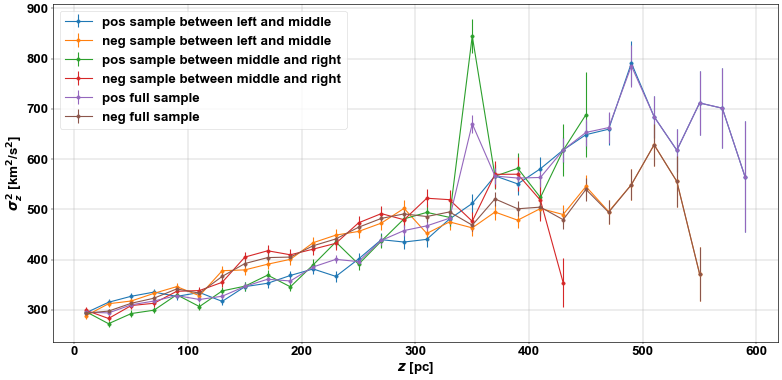

In [12]:
def vel_disp2(left, right, label, n_bins):

    tab_filtered = filtration(left, right)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) +14.5 #correction for height of the sun above the galactic plane

    # Compute vertical velocity dispersion
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv = np.isfinite(vz)
    vz = vz[hasv]
    z_np = z_np[hasv]
    vz_mean = np.genfromtxt(f'data_with_correction/poly_full_{ou}.txt')[2]
    print('velocity data of ', len(z_np), ' stars.')

    bins = np.linspace(-1800, 1800, n_bins+1)
    vz_vars = np.array([])
    evz_means = np.array([])
    evz_vars = np.array([])
    for i in range(len(bins)-1):
        mask = (z_np >= bins[i]) & (z_np < bins[i+1])
        if sum(mask) >= 40: #only intervals with more than 40 stars are considered, to ensure that the gamma distribution is sufficiently Gaussian
            vz_vars = np.append(vz_vars, np.sum((vz[mask]-vz_mean)**2/(sum(mask)))) # as reference mean value for the calculation of variance the mean of all data is used
            evz_means = np.append(evz_means, vz_vars[-1]/np.sqrt(np.sum(mask)))
            evz_vars = np.append(evz_vars, vz_vars[-1]*np.sqrt(2/(np.sum(mask)-1)))
        else:
            vz_vars = np.append(vz_vars, np.nan)
            evz_means = np.append(evz_means, np.nan)
            evz_vars = np.append(evz_vars, np.nan)
    
    # old stuff
    #     if i == 230:
    #         print(vz[mask])
    # print(vz_vars[230])
    # print(evz_means[230])
    # print(evz_vars[230])
    
    z = (bins[1:]+bins[:-1])/2
    i = np.isnan(vz_vars)

    return vz_mean, vz_vars[~i], evz_means[~i], evz_vars[~i], z[~i] #returns the used velocity mean, the variance of the velocity in each bin, the error of the means (only needed in the process for error of variance) and the error of the variance on each of the intervals

# Visualisation and saving of results
fig, ax = plt.subplots(1,1, figsize=(20,10))
ax = [0, ax]
for am, n_bin, title in zip([[left, middle, f'upper_{ou}'], [middle, right, f'lower_{ou}'], [left,right, f'full_{ou}']], [180, 180, 180], ['sample between left and middle', 'sample between middle and right', 'full sample']):
    vz_mean, vz_vars, evz_means, evz_vars, z= vel_disp2(*am, n_bin)
    pos = np.where(z>=0)
    neg = np.where(z<0)
    # ax[0].errorbar(z[pos], vz_mean*np.ones(len(z[pos])), yerr=evz_means[pos], marker='o',label=f"pos")
    # ax[0].errorbar(abs(z[neg]), vz_mean*np.ones(len(z[neg])), yerr=evz_means[neg], marker='o',label=f"neg")
    ax[1].errorbar(z[pos], vz_vars[pos], yerr=evz_vars[pos], marker='o', label=f"pos {title}")
    ax[1].errorbar(abs(z[neg]), vz_vars[neg], yerr=evz_vars[neg], marker='o', label=f"neg {title}")
    data = {
        'z': z,
        'vz_mean': vz_mean,
        'vz_vars': vz_vars,
        'evz_means': evz_means,
        'evz_vars': evz_vars
    }
    df = pd.DataFrame(data)
    df.to_csv(rf'data_with_correction/v2_bin_{am[2]}.txt', index=False, sep=',', header=True)
# ax[0].set_xlabel(r"$z$ [pc]")
# ax[0].set_ylabel(r"$\mu_z$ [km/s]")
# ax[0].grid()
# ax[0].legend()
ax[1].set_xlabel(r"$z$ [pc]")
ax[1].set_ylabel(r"$\sigma_z^2$ [km$^2$/s$^2$]")
ax[1].grid()
ax[1].legend()
plt.tight_layout()
# fig.subplots_adjust(hspace=0.0)
plt.savefig("plots/Vertical_velocity_dispersion_comparison_colour_new.png")
fig.set_dpi(40)
plt.show()

### Argumentation regarding preprocessing --> How distributed

Requirement: Absolute magnitude between left 6 and right 6.7 border function (gelb). Removes an additional 1.62e+05 sources
We are left with 1.63e+05 sources
velocity data of  130422  stars.
Requirement: Absolute magnitude between left 6.7 and right 7.4 border function (gelb). Removes an additional 1.70e+05 sources
We are left with 1.55e+05 sources
velocity data of  112394  stars.
Requirement: Absolute magnitude between left 6 and right 7.4 border function (gelb). Removes an additional 6.62e+03 sources
We are left with 3.18e+05 sources
velocity data of  242816  stars.


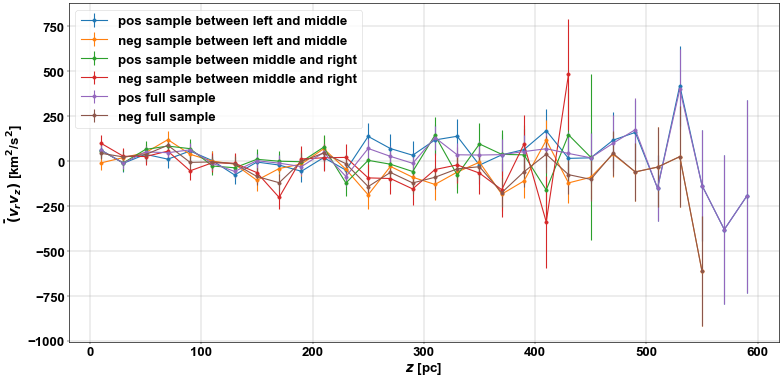

In [19]:
def vel_cor(left, right, label, n_bins):

    tab_filtered = filtration(left, right)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane

    # Compute vertical velocity dispersion
    vz = compute_vz(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    vr = compute_vr(parallax_np, ra_np, dec_np, radial_velocity_np, pmra_np, pmdec_np)
    hasv_z = np.isfinite(vz)
    hasv_r = np.isfinite(vr)
    hasv = hasv_z & hasv_r
    vz = vz[hasv]
    vr = vr[hasv]
    z_np = z_np[hasv]
    vz_mean = np.genfromtxt(f'data_with_correction/poly_full_{ou}.txt')[2]
    print('velocity data of ', len(z_np), ' stars.')

    bins = np.linspace(-1800, 1800, n_bins+1)
    vrz_means = np.array([])
    evrz_means = np.array([])
    for i in range(len(bins)-1):
        mask = (z_np >= bins[i]) & (z_np < bins[i+1])
        if sum(mask) >= 40: #only intervals with more than 40 stars are considered, to ensure that the gamma distribution is sufficiently Gaussian
            vrz_means = np.append(vrz_means, np.sum((vz[mask]-vz_mean)*vr[mask])/(np.sum(mask))) # as reference mean value for the calculation of variance the mean of all data is used (???)
            evrz_means = np.append(evrz_means, np.sqrt( np.sum((vz[mask]-vz_mean)**2*vr[mask]**2)/(np.sum(mask)) - vrz_means[-1]**2) /np.sqrt(np.sum(mask)))
        else:
            vrz_means = np.append(vrz_means, np.nan)
            evrz_means = np.append(evrz_means, np.nan)
    
    z = (bins[1:]+bins[:-1])/2
    i = np.isnan(vrz_means)
    return vz_mean, vrz_means[~i], evrz_means[~i], evrz_means[~i], z[~i] #returns the used z-velocity mean, the correlation of the velocities in each bin, the error of the correlation in each bin 

# Visualisation and saving of results
fig, ax = plt.subplots(1,1, figsize=(20,10))
ax = [0, ax]
for am, n_bin, title in zip([[left, middle, f'upper_{ou}'], [middle, right, f'lower_{ou}'], [left,right, f'full_{ou}']], [180, 180, 180], ['sample between left and middle', 'sample between middle and right', 'full sample']):
    vz_mean, vrz_means, evrz_means, evrz_means, z= vel_cor(*am, n_bin)
    pos = np.where(z>=0)
    neg = np.where(z<0)
    ax[1].errorbar(z[pos], vrz_means[pos], yerr=evrz_means[pos], marker='o', label=f"pos {title}")
    ax[1].errorbar(abs(z[neg]), vrz_means[neg], yerr=evrz_means[neg], marker='o', label=f"neg {title}")
    data = {
        'z': z,
        'vz_mean': vz_mean,
        'vrz_means': vrz_means,
        'evrz_means': evrz_means,
        'evrz_means': evrz_means
    }
    df = pd.DataFrame(data)
    df.to_csv(rf'data_with_correction/vrz_bin_{am[2]}.txt', index=False, sep=',', header=True)
ax[1].set_xlabel(r"$z$ [pc]")
ax[1].set_ylabel(r"$\bar(v_r v_z)$ [km$^2$/s$^2$]")
ax[1].grid()
ax[1].legend()
plt.tight_layout()
# fig.subplots_adjust(hspace=0.0)
plt.savefig("plots/Vertical_radial_velocity_correlation_comparison.png")
fig.set_dpi(40)
plt.show()

### Find estimate on STATISTICAL influence of parallax uncertainty on vertical density fall off

Requirement: Absolute magnitude between left 6 and right 7.4 border function (gelb). Removes an additional 6.62e+03 sources
We are left with 3.18e+05 sources


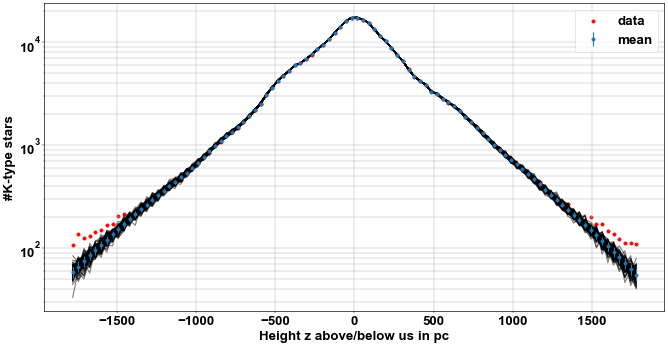

Requirement: Absolute magnitude between left 6 and right 6.7 border function (gelb). Removes an additional 1.62e+05 sources
We are left with 1.63e+05 sources


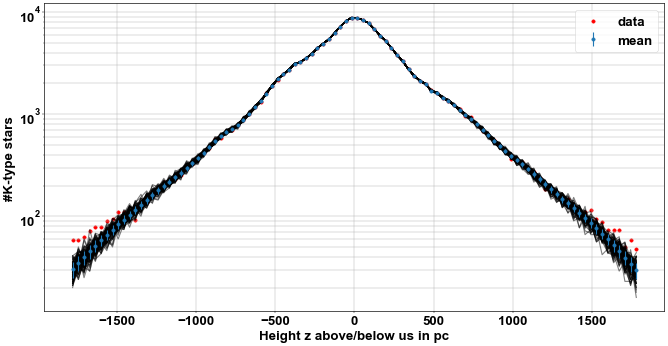

Requirement: Absolute magnitude between left 6.7 and right 7.4 border function (gelb). Removes an additional 1.70e+05 sources
We are left with 1.55e+05 sources


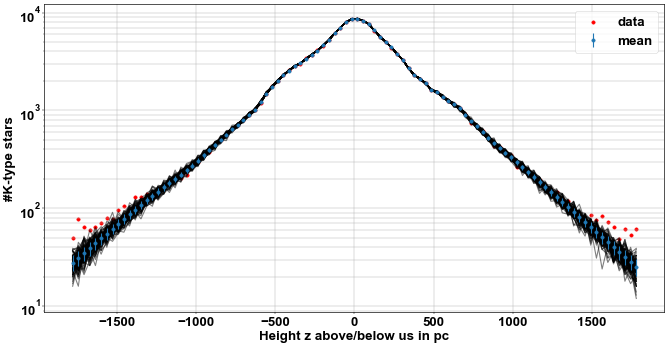

In [13]:
import jax.lax as lax
import jax.random as rand
import jax.numpy as jnp

def params(mean, std):
    'takes arithmetic params and returns classical params of a lognormal distribution'
    mu = jnp.log(mean)-0.5*jnp.log((std/mean)**2+1)
    sigma = jnp.sqrt(jnp.log((std/mean)**2+1))
    return mu, sigma

def sample_log(parallax, parallax_error, n, seed = 42):
    'samples from lognormal distribution'
    key = rand.PRNGKey(seed)
    mu, sigma = params(parallax, parallax_error)
    standard_samp = rand.normal(key, shape=(n, len(parallax)))
    normal_samp = mu[jnp.newaxis,:] + standard_samp*sigma[jnp.newaxis, :]
    lognormal_samp = jnp.exp(normal_samp)
    return lognormal_samp

def sample_gauß(parallax, parallax_error, n, seed = 42):
    'samples from Gaussian distribution'
    key = rand.PRNGKey(seed)
    standard_samp = rand.normal(key, shape=(n, len(parallax)))
    normal_samp = parallax[jnp.newaxis,:] + standard_samp*parallax_error[jnp.newaxis, :]
    return normal_samp

def gauß(x, mu, sigma):
    return 1/(sigma*jnp.sqrt(2*jnp.pi))*jnp.exp(-(x-mu)**2/(2*sigma**2))

def lognormal(x, mu, sigma):
    return 1/(x*sigma*jnp.sqrt(2*jnp.pi))*jnp.exp(-(jnp.log(x)-mu)**2/(2*sigma**2))

def Verarbeitung(left, right, label, n_bin, range, Plot):
    # histogram in z
    tab_filtered = filtration(left, right)
    l_np, b_np, ra_np, ra_error_np, dec_np, dec_error_np, parallax_np, parallax_error_np, pmra_np, pmra_error_np, pmdec_np, pmdec_error_np, phot_g_mean_mag_np, teff_gspphot_np, bp_rp_np, radial_velocity_np, radial_velocity_error_np = arrays(tab_filtered)

    r_np = r_from_plx(parallax_np)
    z_np = r_np * np.sin(b_np*deg2rad) + 14.5 #correction for height of the sun above the galactic plane

    # old stuff
    # minpe = np.where(parallax_np/parallax_error_np == np.min(parallax_np/parallax_error_np))
    # print("Kleinste Parallax/Error: ", (parallax_np/parallax_error_np)[minpe])
    # print("Parallaxe dort: ", parallax_np[minpe])
    # print("Fehler dort: ", parallax_error_np[minpe])
    # print("Kleinste Parallaxe: ", np.min(parallax_np))
    # print("Größte Paraallaxe: ", np.max(parallax_np))
    
    n, bins = np.histogram(z_np, bins=n_bin, range=(-range, range))

    # fig = plt.figure(figsize=(20,10))
    # plt.hist(z_np, bins=n_bin, range=(-range, range))
    # plt.yscale("log")
    # plt.xlabel("Height z above/below us in pc")
    # plt.ylabel("#K-type stars")
    # plt.grid(which='both')
    # fig.set_dpi(40)
    # if Plot:
    #     plt.show()
    # else:
    #     plt.close()

    ''' Sample 3000 times from parallax distribution and calculate density fall off for each sample, neglect systematical change of density fall off, due to trncated sample, determine statistical influence via relative standard deviation (relative to the mean value) per bin, plot and save results'''

    n_samp = 3000
    samples = sample_gauß(parallax_np, parallax_error_np, n_samp) #sampling
    # print(samples[np.where(samples<0)])

    fig = plt.figure(figsize=(20,10))
    r_ = abs(r_from_plx(samples))
    z_ = r_ * jnp.sin(b_np[jnp.newaxis,:]*deg2rad) + 14.5
    bins_, n_ = lax.scan(lambda bins, z: jnp.histogram(z, bins=n_bin, range=(-range, range))[::-1], bins, z_)
    # print(n_.shape)
    for ns in n_[::int(n_samp/100)]:
        plt.plot((bins_[:-1]+bins_[1:])/2, ns, color='black', alpha=0.5)
    n_mean = jnp.mean(n_, axis=0)
    n_std = jnp.std(n_, axis=0, ddof=1)
    # print(n_mean.shape)
    plt.errorbar((bins_[:-1]+bins_[1:])/2, n_mean, yerr=n_std, fmt='o', label='mean')
    plt.scatter((bins[:-1]+bins[1:])/2, n, color='red', label='data')
    plt.yscale("log")
    plt.xlabel("Height z above/below us in pc")
    plt.ylabel("#K-type stars")
    plt.legend()
    plt.grid(which='both')
    fig.set_dpi(40)
    if Plot:
        plt.show()
    else:
        plt.close()

    # Create a text file
    np.savetxt(f'data_with_correction/n_{label}.txt', n, fmt='%i')
    np.savetxt(f'data_with_correction/n_mean_{label}.txt', n_mean, fmt='%f')
    np.savetxt(f'data_with_correction/n_std_{label}.txt', n_std, fmt='%f')
    np.savetxt(f'data_with_correction/bins_{label}.txt', bins, fmt='%f')





    # fig, ax = plt.subplots(2,1, figsize=(20,10))
    # parallax_mean = jnp.mean(samples, axis=0)
    # parallax_std = jnp.std(samples, axis=0, ddof=1)
    # ax[0].errorbar(np.linspace(1,len(parallax_np), len(parallax_np)), parallax_mean, yerr=parallax_std, fmt='x', label='mean', c='blue')
    # ax[0].scatter(np.linspace(1,len(parallax_np), len(parallax_np)), parallax_np, marker='.', label='data', c='red')
    # z_pmean = r_from_plx(parallax_mean) * jnp.sin(b_np*deg2rad) + 14.5
    # z_pstd = z_pmean*parallax_std/parallax_mean
    # n_pmean, bins_pmean = jnp.histogram(z_pmean, bins=n_bin, range=(-range, range))
    # ax[0].grid(which='both')

    # ax[1].plot((bins_pmean[:-1]+bins_pmean[1:])/2, n_pmean, label='mean')
    # ax[1].plot((bins[:-1]+bins[1:])/2, n, label='data')
    # ax[1].grid(which='both')
    # fig.set_dpi(40)
    # if Plot:
    #     plt.show()
    # else:
    #     plt.close()


    # fig, ax = plt.subplots(1,2, figsize=(20,10))
    # n1, bin1, _ = ax[0].hist(n_[:, 10], bins=20)
    # x = np.linspace(n_mean[10]-3*n_std[10], n_mean[10]+3*n_std[10],100)
    # s = jnp.sum(n1)*jnp.abs(bin1[1]-bin1[0])
    # ax[0].plot(x, s*gauß(x, n_mean[10], n_std[10]), label=f'Gauß {n_mean[10]}, {n_std[10]}')
    # ax[0].plot(x, s*lognormal(x, *params(n_mean[10], n_std[10])), label=f'Lognormal')
    # ax[0].grid(which='both')
    # ax[0].legend()
    # n2, bin2, _ = ax[1].hist(n_[:, int(n_bin/2-10)], bins=20)
    # x = np.linspace(n_mean[int(n_bin/2-10)]-3*n_std[int(n_bin/2-10)], n_mean[int(n_bin/2-10)]+3*n_std[int(n_bin/2-10)],100)
    # s = jnp.sum(n2)*jnp.abs(bin2[1]-bin2[0])
    # ax[1].plot(x, s*gauß(x, n_mean[int(n_bin/2-10)], n_std[int(n_bin/2-10)]), label=f'Gauß {n_mean[int(n_bin/2-10)]}, {n_std[int(n_bin/2-10)]}')
    # ax[1].plot(x, s*lognormal(x, *params(n_mean[int(n_bin/2-10)], n_std[int(n_bin/2-10)])), label=f'Lognormal')
    # ax[1].grid(which='both')
    # ax[1].legend()
    # fig.set_dpi(40)
    # if Plot:
    #     plt.show()
    # else:
    #     plt.close()





Verarbeitung(left, right, f'full_{ou}', 100, 1800, True)
Verarbeitung(left, middle, f'upper_{ou}', 100, 1800, True)
Verarbeitung(middle, right, f'lower_{ou}', 100, 1800, True)